In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load data

In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/CPE393/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df['Maker_Model']= df['Make']+ " " + df['Model']

In [4]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Maker_Model
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,BMW 1 Series M
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,BMW 1 Series
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,BMW 1 Series
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450,BMW 1 Series
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500,BMW 1 Series
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120,Acura ZDX
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670,Acura ZDX
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620,Acura ZDX
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920,Acura ZDX


In [5]:
# Select features from original dataset to form a new dataframe
df1 = df[['Engine Fuel Type','Transmission Type','Driven_Wheels','Market Category','Vehicle Size', 'Vehicle Style', 'Maker_Model']]
df1.head()

,Engine Fuel Type,Transmission Type,Driven_Wheels,Market Category,Vehicle Size,Vehicle Style,Maker_Model
0,premium unleaded (required),MANUAL,rear wheel drive,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,BMW 1 Series M
1,premium unleaded (required),MANUAL,rear wheel drive,"Luxury,Performance",Compact,Convertible,BMW 1 Series
2,premium unleaded (required),MANUAL,rear wheel drive,"Luxury,High-Performance",Compact,Coupe,BMW 1 Series
3,premium unleaded (required),MANUAL,rear wheel drive,"Luxury,Performance",Compact,Coupe,BMW 1 Series
4,premium unleaded (required),MANUAL,rear wheel drive,Luxury,Compact,Convertible,BMW 1 Series


In [6]:
# For each row, combine all the columns into one column
df2 = df1.apply(lambda x: ','.join(x.astype(str)), axis=1)
df2.head()

,0
0,"premium unleaded (required),MANUAL,rear wheel ..."
1,"premium unleaded (required),MANUAL,rear wheel ..."
2,"premium unleaded (required),MANUAL,rear wheel ..."
3,"premium unleaded (required),MANUAL,rear wheel ..."
4,"premium unleaded (required),MANUAL,rear wheel ..."


In [7]:
df2.shape

(11914,)

In [8]:
# Store them in a pandas dataframe
df_clean = pd.DataFrame({'clean': df2})
df_clean.head()

,clean
0,"premium unleaded (required),MANUAL,rear wheel ..."
1,"premium unleaded (required),MANUAL,rear wheel ..."
2,"premium unleaded (required),MANUAL,rear wheel ..."
3,"premium unleaded (required),MANUAL,rear wheel ..."
4,"premium unleaded (required),MANUAL,rear wheel ..."


In [9]:
# Create the list of list format of the custom corpus for gensim modeling
sent = [row.split(',') for row in df_clean['clean']]
# show the example of list of list format of the custom corpus for gensim modeling
sent[:2]

[['premium unleaded (required)',
  'MANUAL',
  'rear wheel drive',
  'Factory Tuner',
  'Luxury',
  'High-Performance',
  'Compact',
  'Coupe',
  'BMW 1 Series M'],
 ['premium unleaded (required)',
  'MANUAL',
  'rear wheel drive',
  'Luxury',
  'Performance',
  'Compact',
  'Convertible',
  'BMW 1 Series']]

## Train Word2Vec model (skip-gram)

In [10]:
!pip install gensim

In [11]:
# from gensim import models
from gensim.models import Word2Vec
model = Word2Vec(sent, min_count=1,vector_size= 300,workers=5, window=10, sg = 1, epochs=100)
# model = Word2Vec(sent, min_count=1,size= 300,workers=5, window=10, sg = 1, iter=100)

**vector_size**: The number of dimensions of the embeddings and the default is 100.

**window**: The maximum distance between a target word and words around the target word. The default window is 5.

**min_count**: The minimum count of words to consider when training the model; words with occurrence less than this count will be ignored. The default for min_count is 5.

**workers**: The number of partitions during training and the default workers is 3.

**sg**: The training algorithm, either CBOW(0) or skip gram(1). The default training algorithm is CBOW.

In [12]:
model.wv['Toyota Camry']

array([ 1.47385404e-01,  6.27801269e-02,  5.33101559e-02, -9.07321200e-02,
        1.39081225e-01, -8.97382870e-02, -2.05423608e-02, -3.65444459e-02,
       -8.46286938e-02,  5.02994023e-02,  1.93774566e-01, -8.53577405e-02,
        1.73119336e-01,  1.94758400e-01,  6.14983379e-04, -4.27879244e-02,
        2.30320871e-01,  8.36646929e-02, -7.95617923e-02, -3.30228843e-02,
       -9.66270268e-02, -1.28960282e-01, -1.83718860e-01,  1.95413351e-01,
       -1.88748121e-01, -1.03352770e-01, -1.71399713e-01,  1.53146967e-01,
       -6.38812631e-02, -1.54884025e-01,  4.09680575e-01,  6.94107078e-03,
       -9.48411748e-02, -5.39955720e-02,  2.32925955e-02, -1.00150250e-01,
        7.20573291e-02, -1.41351953e-01, -1.26193436e-02,  5.77153713e-02,
       -3.10708404e-01,  2.95946607e-03,  2.08722055e-01,  2.49710798e-01,
       -1.02214724e-01,  6.94779232e-02, -4.60041687e-02, -7.07566589e-02,
        2.12824598e-01,  2.20088363e-02,  3.17619406e-02, -3.06416631e-01,
       -1.42771574e-02, -

In [13]:
model.wv.similarity('Porsche 718 Cayman', 'Nissan Van')

0.54736257

In [14]:
model.wv.similarity('Porsche 718 Cayman', 'Mercedes-Benz SLK-Class')

0.8255832

In [15]:
model.wv.most_similar('Mercedes-Benz SLK-Class')[:5]

[('Mercedes-Benz SL-Class', 0.9842197299003601),
 ('Cadillac XLR-V', 0.9775272607803345),
 ('Mercedes-Benz SLC-Class', 0.9453487992286682),
 ('BMW Z4 M', 0.9263644218444824),
 ('Porsche Boxster', 0.9226880073547363)]

In [16]:
model

In [17]:
import numpy as np
def cosine_distance (model, word,target_list , num) :
    cosine_dict ={}
    word_list = []
    a = model.wv[word]
    for item in target_list :
        if item != word :
            b = model.wv[item]
            cos_sim = np.dot(a, b)/(np.linalg.norm(a)*np.linalg.norm(b))
            cosine_dict[item] = cos_sim
    dist_sort=sorted(cosine_dict.items(), key=lambda dist: dist[1],reverse = True) ## in Descending order
    for item in dist_sort:
        word_list.append((item[0], item[1]))
    return word_list[0:num]

In [18]:
# only get the unique Maker_Model
Maker_Model = list(df.Maker_Model.unique())

# Show the most similar Mercedes-Benz SLK-Class by cosine distance
cosine_distance(model,'Mercedes-Benz SLK-Class',Maker_Model,5)


[('Mercedes-Benz SL-Class', 0.98421973),
 ('Cadillac XLR-V', 0.9775273),
 ('Mercedes-Benz SLC-Class', 0.9453488),
 ('BMW Z4 M', 0.9263644),
 ('Porsche Boxster', 0.922688)]

# Activity

1. Use the customer complaint data to estimate the word embedding vectors
2. Find similar words to 'debt', 'collection', 'risk'

In [19]:
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/CPE393/consumer_complaint_dataset.data', compression='gzip')

## EDA

In [20]:
df.head(10)

,topic,input
0,Debt collection,transworld systems inc. \nis trying to collect...
1,"Credit reporting, credit repair services, or o...",I would like to request the suppression of the...
2,Debt collection,"Over the past 2 weeks, I have been receiving e..."
3,"Credit reporting, credit repair services, or o...",I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...
4,"Credit reporting, credit repair services, or o...",I have several accounts that the balance is in...
5,"Money transfer, virtual currency, or money ser...","I was sold access to an event digitally, of wh..."
6,Debt collection,While checking my credit report I noticed thre...
7,"Credit reporting, credit repair services, or o...",I would like the credit bureau to correct my X...
8,"Credit reporting, credit repair services, or o...",MY NAME IS XXXX XXXX XXXX I live at XXXX XXXX ...
9,"Credit reporting, credit repair services, or o...",Today XX/XX/XXXX went online to dispute the in...


In [21]:
df.shape

(492255, 2)

In [22]:
df['topic'].value_counts()

,count
topic,
"Credit reporting, credit repair services, or other personal consumer reports",145090
Debt collection,106946
Mortgage,61581
Credit card or prepaid card,32144
Credit reporting,31588
Student loan,25083
Checking or savings account,19153
Credit card,18838
Bank account or service,14885


In [23]:
df['sum'] = df['topic'] + ' ' + df['input']
df['sum'].head()

,sum
0,Debt collection transworld systems inc. \nis t...
1,"Credit reporting, credit repair services, or o..."
2,"Debt collection Over the past 2 weeks, I have ..."
3,"Credit reporting, credit repair services, or o..."
4,"Credit reporting, credit repair services, or o..."


In [24]:
input_text = df['sum'].tolist()
input_text[:10]

['Debt collection transworld systems inc. \nis trying to collect a debt that is not mine, not owed and is inaccurate.',
 'Credit reporting, credit repair services, or other personal consumer reports I would like to request the suppression of the following items from my credit report, which are the result of my falling victim to identity theft. This information does not relate to [ transactions that I have made/accounts that I have opened ], as the attached supporting documentation can attest. As such, it should be blocked from appearing on my credit report pursuant to section 605B of the Fair Credit Reporting Act.',
 'Debt collection Over the past 2 weeks, I have been receiving excessive amounts of telephone calls from the company listed in this complaint. The calls occur between XXXX XXXX and XXXX XXXX to my cell and at my job. The company does not have the right to harass me at work and I want this to stop. It is extremely distracting to be told 5 times a day that I have a call from 

## Prepare Data

In [25]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
import re
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag


lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# remove masked info
def remove_masking(text):
    text = text.lower()
    masked_pattern = re.compile(r'xx+', re.IGNORECASE)
    return masked_pattern.sub('', text)

# POS tag
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# clean + tokenize + lemmatize
def clean_text(text: str):
    text = remove_masking(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    pos_tags = pos_tag(tokens)

    lemmatized = [
        lemmatizer.lemmatize(w, get_wordnet_pos(tag))
        for w, tag in pos_tags if w not in stop_words
    ]
    return lemmatized

# ใช้กับ list ของข้อความ
def preprocess_text(text_list):
    return [clean_text(text) for text in text_list]


In [27]:
sample = ["Cats are running in the fields. xxxx",
          "Children studied harder for exams."]

print(preprocess_text(sample))


[['cat', 'run', 'field'], ['child', 'study', 'harder', 'exam']]


In [28]:
text = preprocess_text(input_text)

In [38]:
with open("/content/drive/MyDrive/CPE393/preprocess_text.txt", "w", encoding="utf-8") as f:
    for doc in text:
        f.write(" ".join(doc) + "\n")

In [40]:
# Train Word2Vec model
w2v_model = Word2Vec(sentences=text,
                     vector_size=100,   # embedding size
                     window=10,         # context window
                     min_count=1,
                     workers=5,
                     sg=1,              # skip-gram
                     epochs=10)

In [41]:
print(f"Vocabulary size: {len(model.wv)}")
print("Sample words:", list(model.wv.index_to_key[:20]))

Vocabulary size: 977
Sample words: ['AUTOMATIC', 'regular unleaded', 'front wheel drive', 'Compact', 'Midsize', 'nan', 'rear wheel drive', 'Luxury', 'Sedan', 'MANUAL', 'Large', '4dr SUV', 'all wheel drive', 'Performance', 'Crossover', 'premium unleaded (required)', 'premium unleaded (recommended)', 'four wheel drive', 'High-Performance', 'Coupe']


In [44]:
w2v_model.save("/content/drive/MyDrive/CPE393/complaints_w2v.model")

In [49]:
words_to_check = ["debt", "collection", "risk"]

for word in words_to_check:
    if word in w2v_model.wv.key_to_index:  # ตรวจสอบว่ามีใน vocab
        similar_words = w2v_model.wv.most_similar(word, topn=10)
        print(f"similar '{word}':")
        for sim_word, score in similar_words:
            print(f"  {sim_word}: {score:.4f}")
        print("-" * 30)
    else:
        print(f"'{word}' not in vocab")
        print("-" * 30)


similar 'debt':
  collection: 0.8088
  collector: 0.8002
  allged: 0.7636
  reponddispute: 0.7626
  outsourcings: 0.7623
  outsoursing: 0.7595
  direcmanagement: 0.7519
  receiveable: 0.7470
  fromamountdate: 0.7454
  outsorcing: 0.7398
------------------------------
similar 'collection':
  debt: 0.8088
  businesscollection: 0.7706
  receiveable: 0.7606
  natlcrsys: 0.7529
  floridabased: 0.7493
  incregarding: 0.7429
  systemspursuant: 0.7333
  outsoursing: 0.7324
  carpio: 0.7297
  originalactual: 0.7271
------------------------------
similar 'risk':
  everpresent: 0.7097
  wwwequifaxsecurity: 0.7094
  liferuining: 0.7053
  mpact: 0.6900
  exposure: 0.6893
  misshandling: 0.6790
  reputational: 0.6700
  equifaxsecuirtycom: 0.6698
  highalert: 0.6672
  itcybersecurity: 0.6556
------------------------------


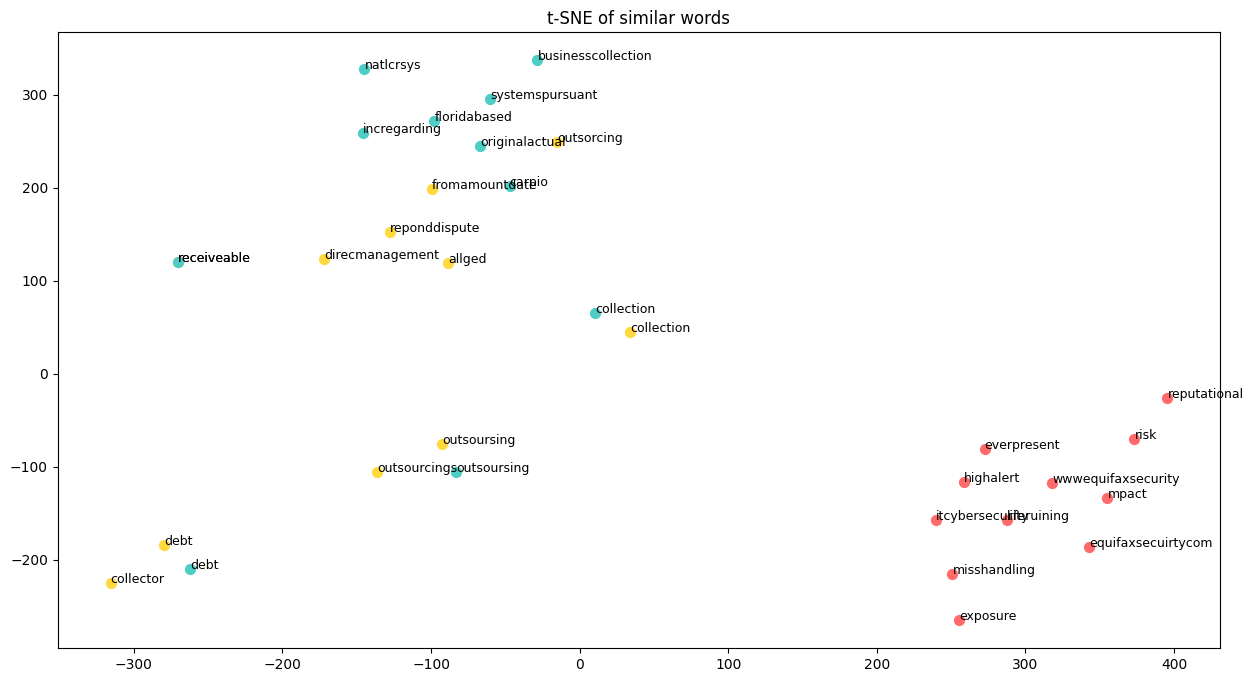

In [66]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

targets = words_to_check
topn = 10

words = []
vectors = []
colors = []

color_map = {
    "debt": "#FFD93D",
    "collection": "#4ECDC4",
    "risk": "#FF6B6B"
}


for target in targets:
    if target in w2v_model.wv:
        sims = [w for w, _ in w2v_model.wv.most_similar(target, topn=topn)]
    else:
        sims = []

    # target word itself
    words.append(target)
    vectors.append(w2v_model.wv[target])
    colors.append(color_map[target])

    # similar words
    for w in sims:
        words.append(w)
        vectors.append(w2v_model.wv[w])
        colors.append(color_map[target])

vectors = np.array(vectors)

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)

plt.figure(figsize=(15,8))
for i, word in enumerate(words):
    plt.scatter(vectors_2d[i,0], vectors_2d[i,1], color=colors[i], s=50)
    plt.text(vectors_2d[i,0]+0.1, vectors_2d[i,1]+0.1, word, fontsize=9)

plt.title("t-SNE of similar words")
plt.show()

*🌸 Punchaya Chancharoen 65070507236 🌸*
